In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
model = joblib.load("../models/best_house_price_model.pkl")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

In [3]:
predictions = model.predict(X_test)

In [4]:
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")

R² Score : 0.6647
MAE      : 964058.87
RMSE     : 1301871.87


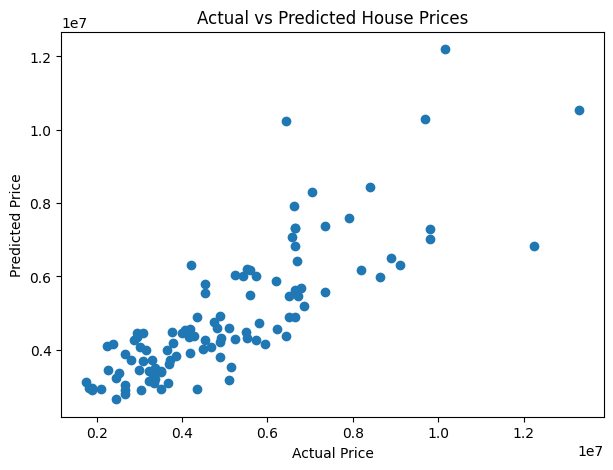

In [5]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

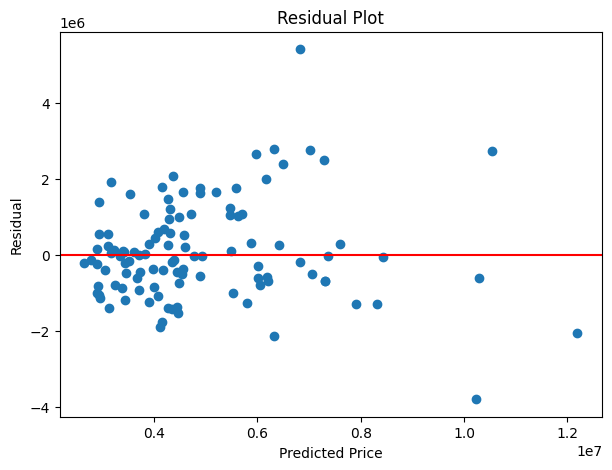

In [6]:
residuals = y_test - predictions

plt.figure(figsize=(7,5))

plt.scatter(predictions, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [7]:
importance = model.feature_importances_

features = X_test.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,area,0.460977
2,bathrooms,0.167077
8,airconditioning,0.090974
9,parking,0.051458
3,stories,0.045738
1,bedrooms,0.045588
11,furnishingstatus,0.032947
6,basement,0.031763
10,prefarea,0.026818
4,mainroad,0.016710


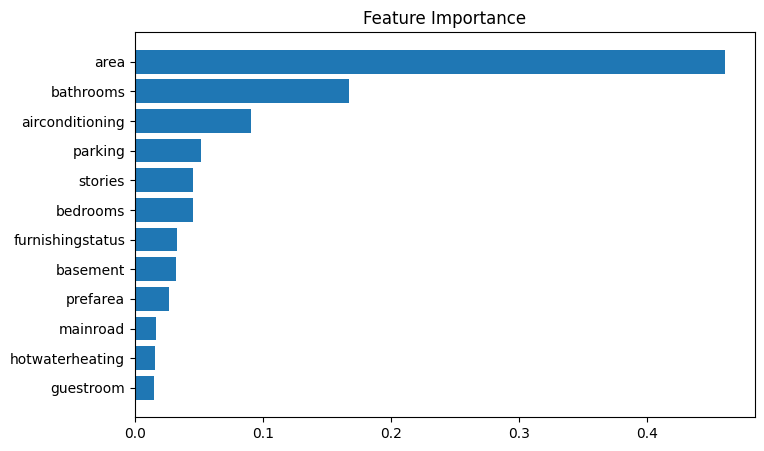

In [8]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [9]:
importance_df.to_csv(
    "../reports/feature_importance.csv",
    index=False
)